# Separate Valence and Arousal Searchlight RSA

Previous analyses used a joint VA RDM (Euclidean distance in 2D valence-arousal space).
This notebook separates them into three model RDMs:
1. **Valence-only**: absolute difference in valence ratings
2. **Arousal-only**: absolute difference in arousal ratings
3. **Joint VA**: Euclidean distance in 2D VA space (for comparison)

Searchlight RSA at FDR 0.05, 0.01, 0.001.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from tqdm import tqdm
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from scipy.stats import ttest_1samp, spearmanr
from statsmodels.stats.multitest import fdrcorrection
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from rsatoolbox.util.searchlight import evaluate_models_searchlight
from rsatoolbox.model import ModelFixed
from rsatoolbox.inference import eval_fixed

os.makedirs('./outputs/tBrainmap', exist_ok=True)
print('Imports OK')

Imports OK


In [2]:
# =====================================================================
# CONFIG
# =====================================================================

# Trial file with VA scores
IAPS_TRIAL_CSV = r"..\IAPS_behavioral_RDM\fmri_conditions_trial_ordered.csv"

# IAPS image order file
IAPS_ORDER_CSV = r"..\IAPS_Searchlight\IAPS_60_pnu.csv"

# fMRI searchlight data
FMRI_DATA_DIR = r"."
TMP_IMG_PATH  = os.path.join(FMRI_DATA_DIR, 'tmp.img')
MASK_PATH     = os.path.join(FMRI_DATA_DIR, 'mask.npy')
ALLSUB_PATH   = os.path.join(FMRI_DATA_DIR, 'allsub_avg.npy')

# Searchlight parameters
SL_RADIUS    = 5
SL_THRESHOLD = 0.5
N_JOBS       = 6

# Statistics
FDR_ALPHAS        = [0.05, 0.01, 0.001]
CLUSTER_THRESHOLD = 30

N_STIMULI = 60

In [3]:
def upper_tri(RDM):
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


def normalize_rdm(rdm):
    mn, mx = rdm.min(), rdm.max()
    if mx - mn == 0:
        return rdm
    return (rdm - mn) / (mx - mn)

## 1. Load VA scores and build separate RDMs

In [4]:
# Extract unique stimuli with VA scores, sorted Pl/Nt/Up by stim_order
iaps_file = pd.read_csv(IAPS_TRIAL_CSV)

iaps_unique_count = (
    iaps_file[['iaps_id', 'type', 'category', 'stim_order', 'Mean_Valence', 'Mean_Arousal']]
    .value_counts()
    .reset_index(name='count')
)
iaps_unique_count['type'] = pd.Categorical(iaps_unique_count['type'], ['Pl', 'Nt', 'Up'])
iaps_unique = iaps_unique_count.sort_values(by=['type', 'stim_order'])
iaps_behave_raw = iaps_unique.drop(columns=['count']).reset_index(drop=True)

assert len(iaps_behave_raw) == N_STIMULI

valence = iaps_behave_raw['Mean_Valence'].values  # (60,)
arousal = iaps_behave_raw['Mean_Arousal'].values   # (60,)

print(f'Valence range: {valence.min():.2f} - {valence.max():.2f}')
print(f'Arousal range: {arousal.min():.2f} - {arousal.max():.2f}')

# Load IAPS order for labeling
iaps_order = pd.read_csv(IAPS_ORDER_CSV)
iaps_ids = [str(x) for x in iaps_order['iaps_id']]

Valence range: 1.45 - 7.83
Arousal range: 2.86 - 7.35


In [5]:
# Valence-only RDM: absolute difference in valence
valence_rdm = np.abs(valence[:, None] - valence[None, :])  # (60, 60)
np.fill_diagonal(valence_rdm, 0)

# Arousal-only RDM: absolute difference in arousal
arousal_rdm = np.abs(arousal[:, None] - arousal[None, :])  # (60, 60)
np.fill_diagonal(arousal_rdm, 0)

# Joint VA RDM: Euclidean distance in 2D VA space
va_scores = np.column_stack([valence, arousal])  # (60, 2)
va_rdm = pairwise_distances(va_scores, metric='euclidean')
np.fill_diagonal(va_rdm, 0)

# Normalize all to [0, 1]
valence_rdm = normalize_rdm(valence_rdm)
arousal_rdm = normalize_rdm(arousal_rdm)
va_rdm = normalize_rdm(va_rdm)

print(f'Valence RDM: {valence_rdm.shape}')
print(f'Arousal RDM: {arousal_rdm.shape}')
print(f'Joint VA RDM: {va_rdm.shape}')

# Cross-correlations
r_val_aro, _ = spearmanr(upper_tri(valence_rdm), upper_tri(arousal_rdm))
r_val_va, _  = spearmanr(upper_tri(valence_rdm), upper_tri(va_rdm))
r_aro_va, _  = spearmanr(upper_tri(arousal_rdm), upper_tri(va_rdm))

print(f'\nRDM correlations (Spearman):')
print(f'  Valence vs Arousal:  r = {r_val_aro:.3f}')
print(f'  Valence vs Joint VA: r = {r_val_va:.3f}')
print(f'  Arousal vs Joint VA: r = {r_aro_va:.3f}')

Valence RDM: (60, 60)
Arousal RDM: (60, 60)
Joint VA RDM: (60, 60)

RDM correlations (Spearman):
  Valence vs Arousal:  r = 0.065
  Valence vs Joint VA: r = 0.898
  Arousal vs Joint VA: r = 0.396


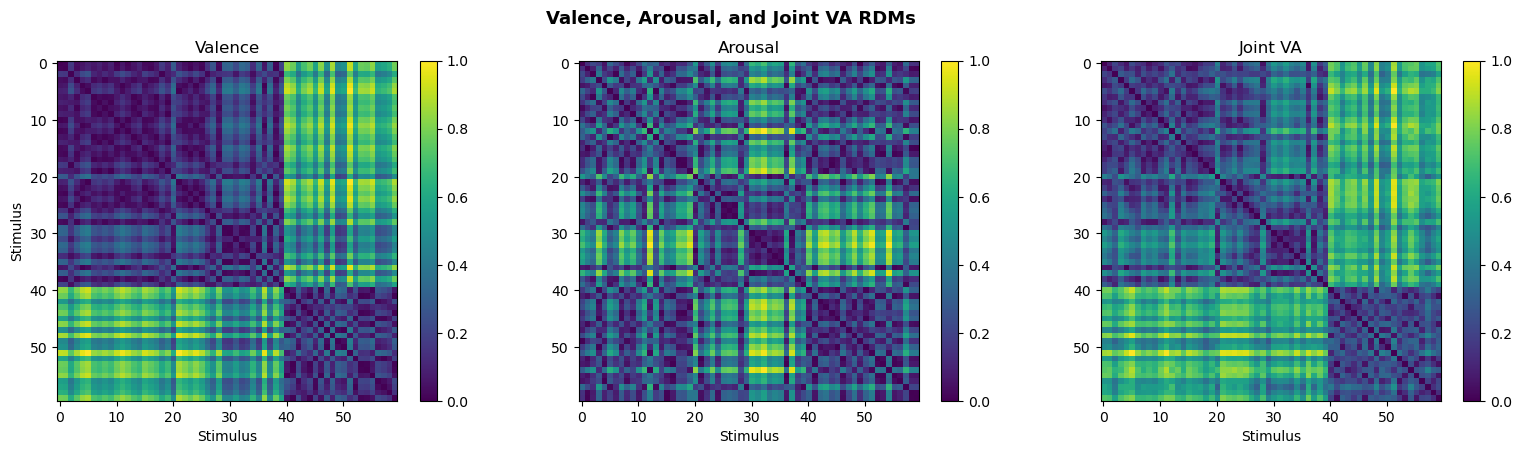

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

rdm_list = [
    ('Valence', valence_rdm),
    ('Arousal', arousal_rdm),
    ('Joint VA', va_rdm),
]

for ax, (name, rdm) in zip(axes, rdm_list):
    im = ax.imshow(rdm, cmap='viridis', aspect='equal')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Stimulus')
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[0].set_ylabel('Stimulus')
plt.suptitle('Valence, Arousal, and Joint VA RDMs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/valence_arousal_separate_RDMs.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
pd.DataFrame(valence_rdm, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_valence.csv')
pd.DataFrame(arousal_rdm, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_arousal.csv')
pd.DataFrame(va_rdm, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_VA_joint.csv')
print('Saved all 3 RDMs.')

Saved all 3 RDMs.


## 2. Load fMRI data and build searchlight

In [8]:
tmp_img = nib.load(TMP_IMG_PATH)
mask = np.load(MASK_PATH)
allsub_avg = np.load(ALLSUB_PATH, allow_pickle=True)
centers, neighbors = get_volume_searchlight(mask, radius=SL_RADIUS, threshold=SL_THRESHOLD)

print(f'Mask shape: {mask.shape}')
print(f'Subject data shape: {allsub_avg.shape}')
print(f'Searchlight centers: {len(centers)}')

Finding searchlights...: 100%|██████████| 59159/59159 [00:07<00:00, 8236.60it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Subject data shape: (20, 60, 153594)
Searchlight centers: 56949


## 3. Searchlight RSA functions

In [9]:
def run_searchlight_for_model(model_name, model_rdm, allsub_avg, centers, neighbors, mask):
    model_obj = ModelFixed(model_name, upper_tri(model_rdm))

    eval_score_list = []
    RDM_brain_list = []
    x, y, z = mask.shape

    for i in tqdm(range(allsub_avg.shape[0]), desc=f'{model_name}'):
        subj_data = np.nan_to_num(allsub_avg[i])
        image_value = np.arange(subj_data.shape[0])

        SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')

        eval_results = evaluate_models_searchlight(SL_RDM, model_obj, eval_fixed, method='spearman', n_jobs=N_JOBS)
        eval_score = [float(e.evaluations) for e in eval_results]

        RDM_brain = np.zeros(x * y * z)
        RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
        RDM_brain = RDM_brain.reshape(x, y, z)

        eval_score_list.append(eval_score)
        RDM_brain_list.append(RDM_brain)

    voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])
    return np.array(eval_score_list), RDM_brain_list, voxel_indices


def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                             fdr_alpha=0.001, cluster_threshold=30,
                             model_name='', t_value_threshold=None):
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)

    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0, nan_policy='omit')

    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_mask = rejected

    if t_value_threshold is not None:
        sig_mask = sig_mask & (t_stats >= t_value_threshold)
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha} AND t >= {t_value_threshold})")
    else:
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha})")

    sig_voxels = np.where(sig_mask)[0]

    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)

    t_map_3d[t_map_3d < 0] = np.nan

    t_img = new_img_like(tmp_img, t_map_3d)

    t_img_cluster = nlimg.threshold_img(
        t_img,
        threshold=0,
        cluster_threshold=cluster_threshold
    )

    return t_img_cluster, t_stats, p_fdr

## 4. Run searchlight RSA for Valence, Arousal, and Joint VA

In [10]:
models_to_run = {
    'Valence':  valence_rdm,
    'Arousal':  arousal_rdm,
    'Joint_VA': va_rdm,
}

results = {}

for model_name, model_rdm in models_to_run.items():
    print(f"\n{'='*60}")
    print(f"  Running searchlight for: {model_name}")
    print(f"{'='*60}")

    eval_scores, rdm_brains, voxel_ids = run_searchlight_for_model(
        model_name, model_rdm, allsub_avg, centers, neighbors, mask
    )

    pd.DataFrame(eval_scores).to_csv(f'./outputs/20sub_SL_eval_{model_name}.csv')
    np.save(f'./outputs/20sub_SL_eval_{model_name}.npy', eval_scores)
    print(f'Saved. Shape: {eval_scores.shape}')

    results[model_name] = {
        'eval_scores': eval_scores,
        'voxel_ids': voxel_ids,
    }


  Running searchlight for: Valence


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:23<00:00, 2380.48it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11900\2825017550.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
Valence: 100%|██████████| 20/20 [52:51<00:00, 158.59s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: Arousal


Arousal: 100%|██████████| 20/20 [24:53<00:00, 74.70s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: Joint_VA


Joint_VA:  15%|█▌        | 3/20 [06:23<38:41, 136.58s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
Joint_VA: 100%|██████████| 20/20 [46:31<00:00, 139.56s/it]


Saved. Shape: (20, 56949)


## 5. Group statistics and t-maps (FDR 0.05, 0.01, 0.001)

In [11]:
tmaps = {}  # {model_name: {fdr_alpha: tmap_img}}

for model_name, res in results.items():
    tmaps[model_name] = {}
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for fdr_alpha in FDR_ALPHAS:
        fdr_label = str(fdr_alpha).replace('0.', '').replace('.', '')

        tmap, t_stats, p_fdr = compute_tmap_from_scores(
            res['eval_scores'], res['voxel_ids'], mask.shape, tmp_img,
            fdr_alpha=fdr_alpha,
            cluster_threshold=CLUSTER_THRESHOLD,
            model_name=model_name,
            t_value_threshold=None
        )

        out_path = f'./outputs/tBrainmap/tmap_{model_name}_fdr{fdr_label}.nii.gz'
        nib.save(tmap, out_path)
        print(f'  Saved: {out_path}')

        tmaps[model_name][fdr_alpha] = tmap


  Valence
Valence: 2731 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_Valence_fdr05.nii.gz
Valence: 1192 significant voxels (FDR q < 0.01)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11900\2825017550.py:59: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11900\2825017550.py:59: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(


  Saved: ./outputs/tBrainmap/tmap_Valence_fdr01.nii.gz
Valence: 289 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_Valence_fdr001.nii.gz

  Arousal
Arousal: 28290 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_Arousal_fdr05.nii.gz
Arousal: 15857 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_Arousal_fdr01.nii.gz
Arousal: 4777 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_Arousal_fdr001.nii.gz

  Joint_VA
Joint_VA: 2616 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_Joint_VA_fdr05.nii.gz
Joint_VA: 865 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_Joint_VA_fdr01.nii.gz
Joint_VA: 125 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_Joint_VA_fdr001.nii.gz


## 6. Visualize t-maps


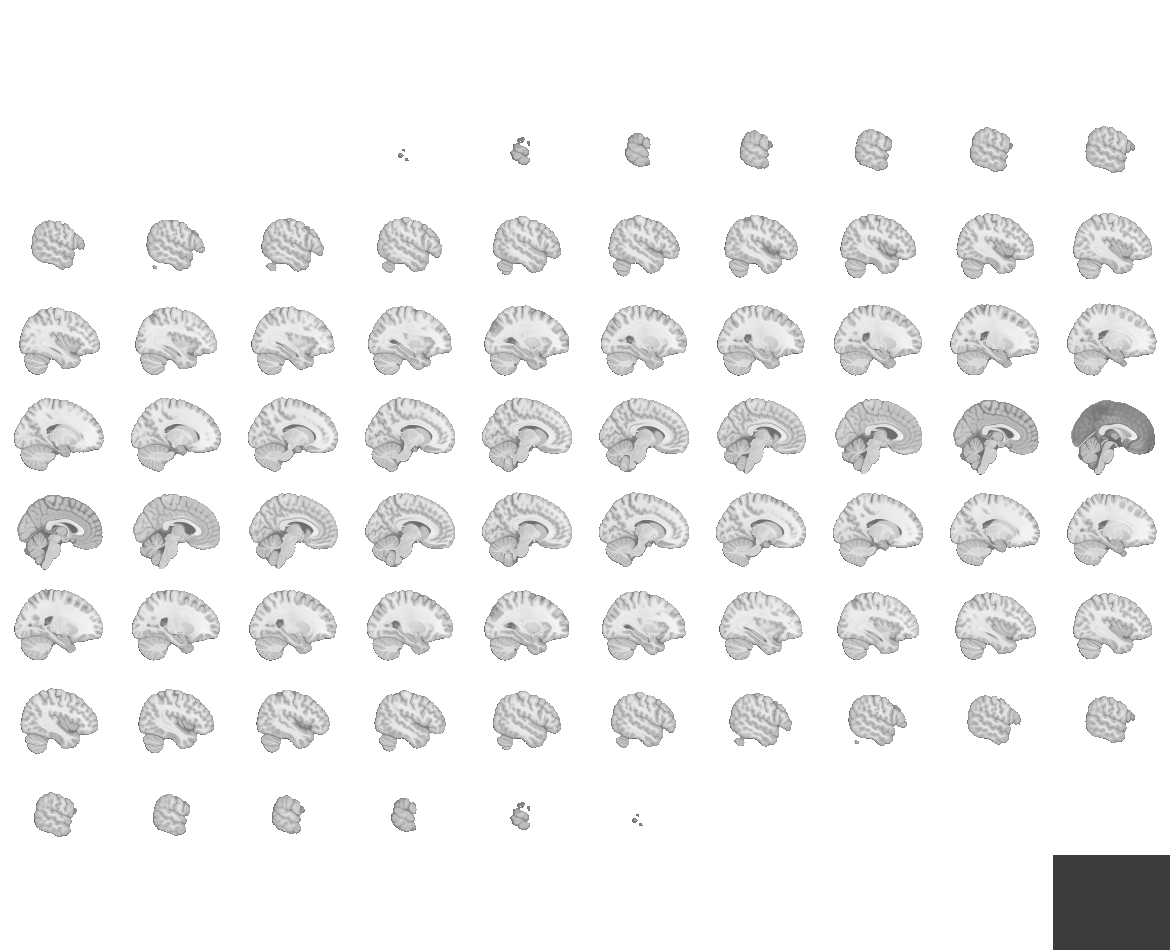
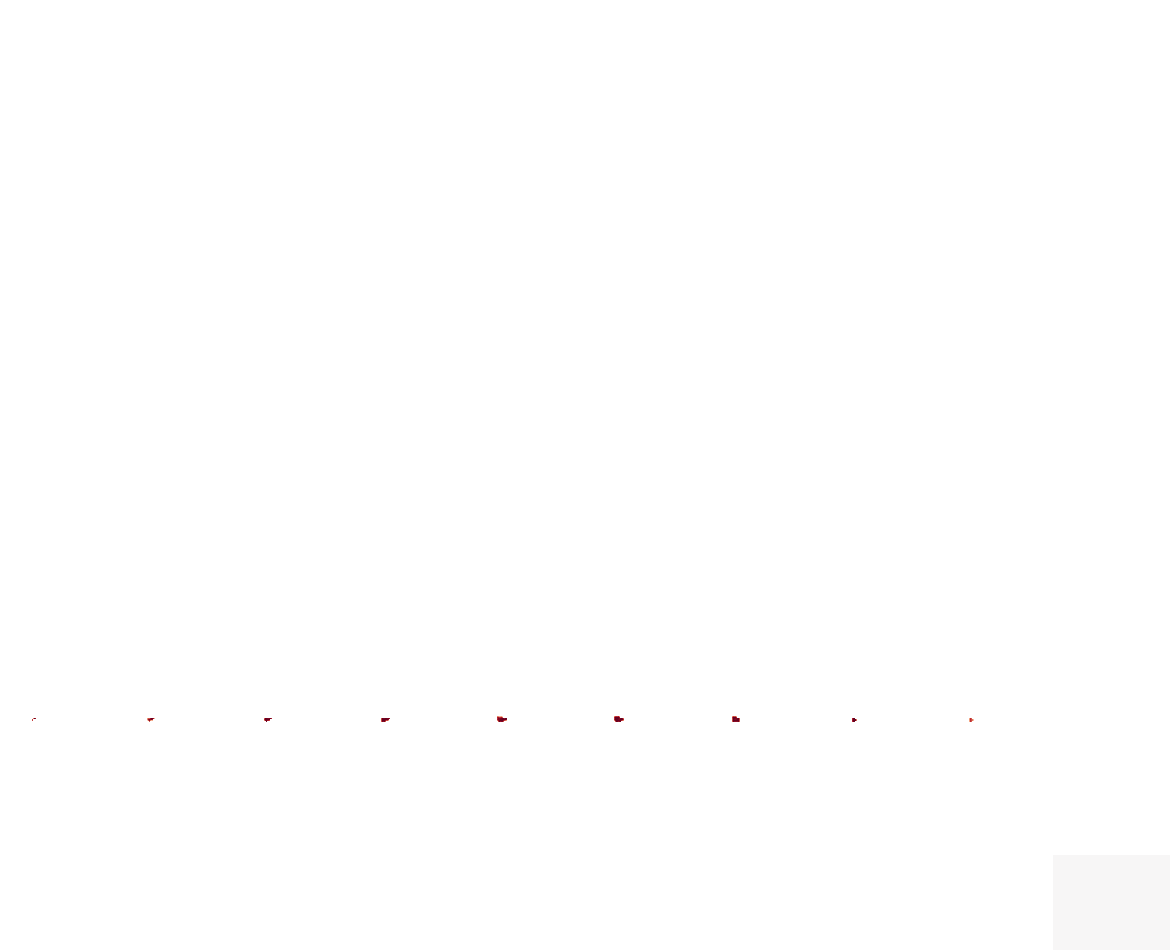


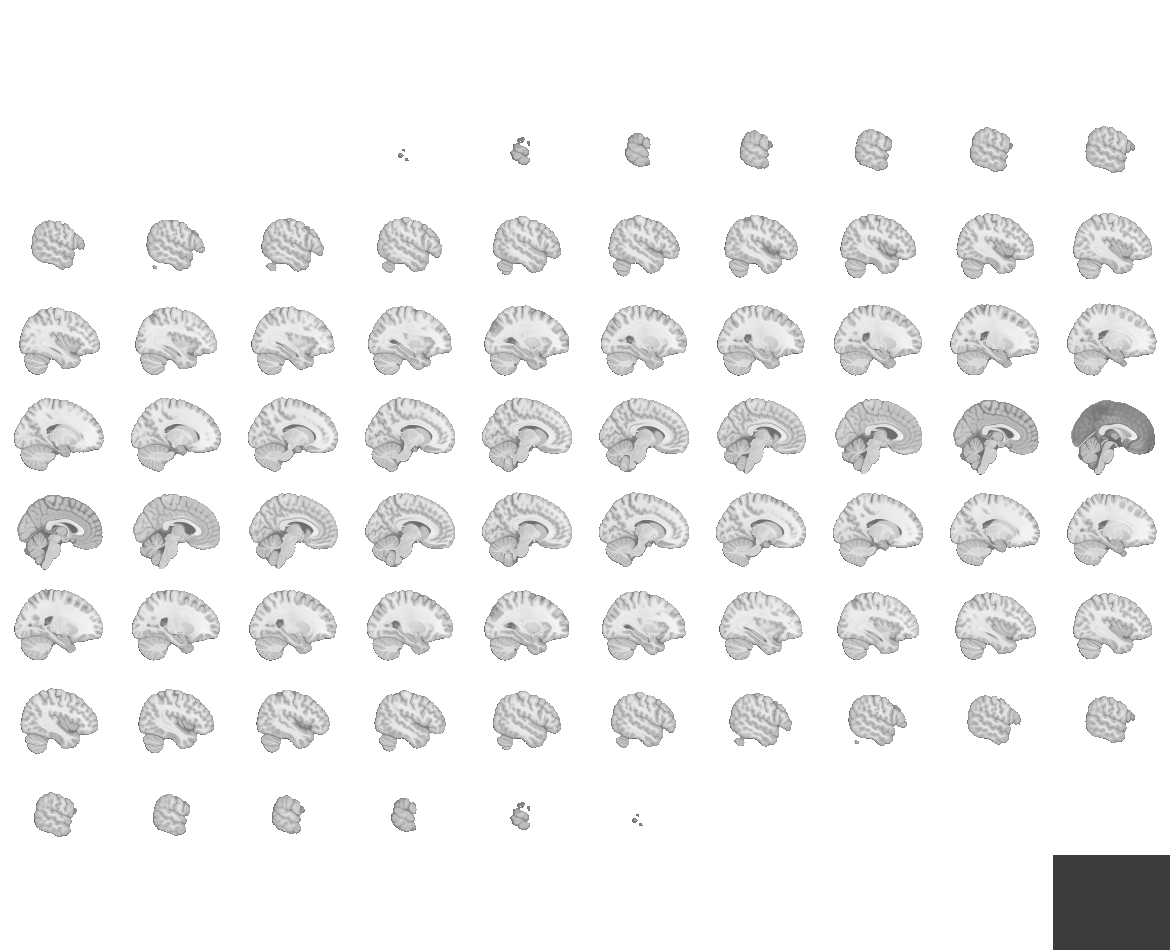
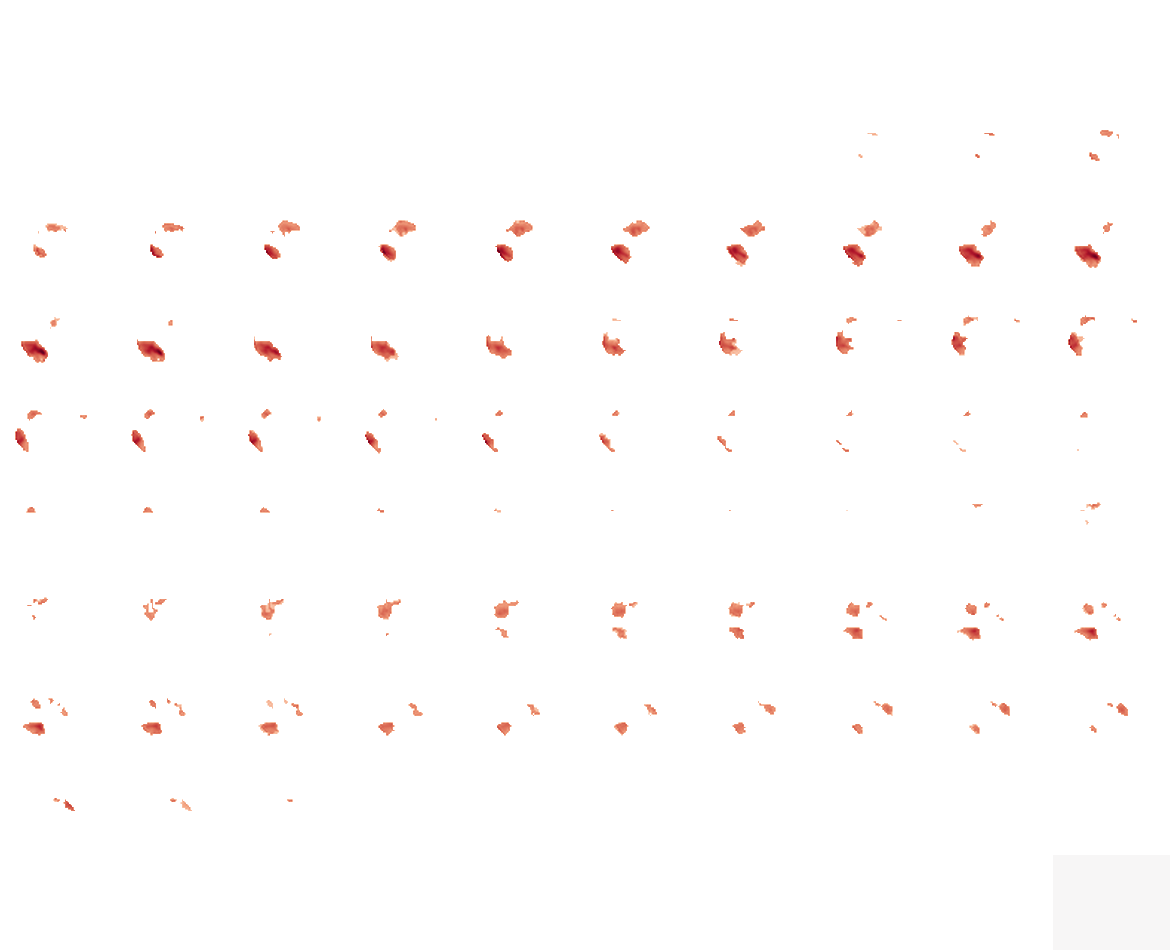


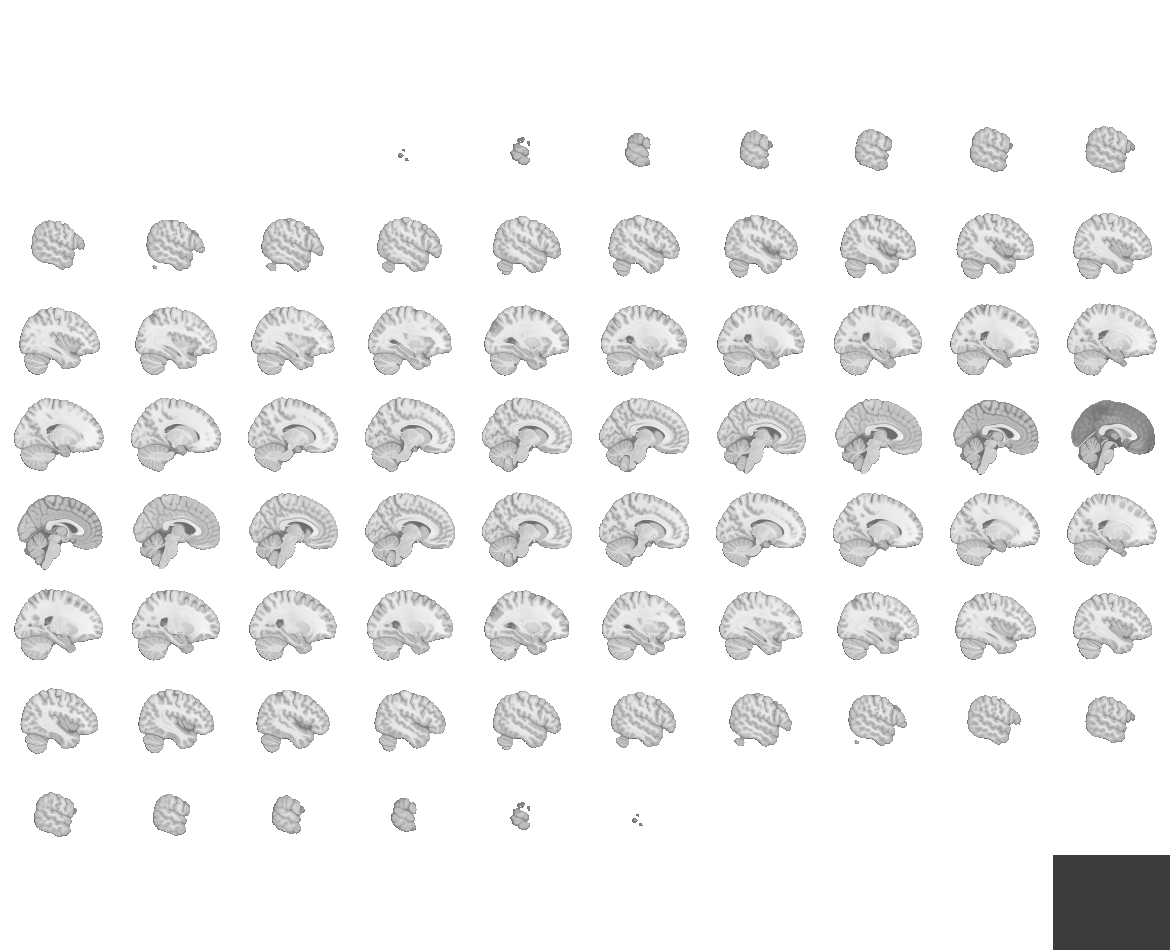
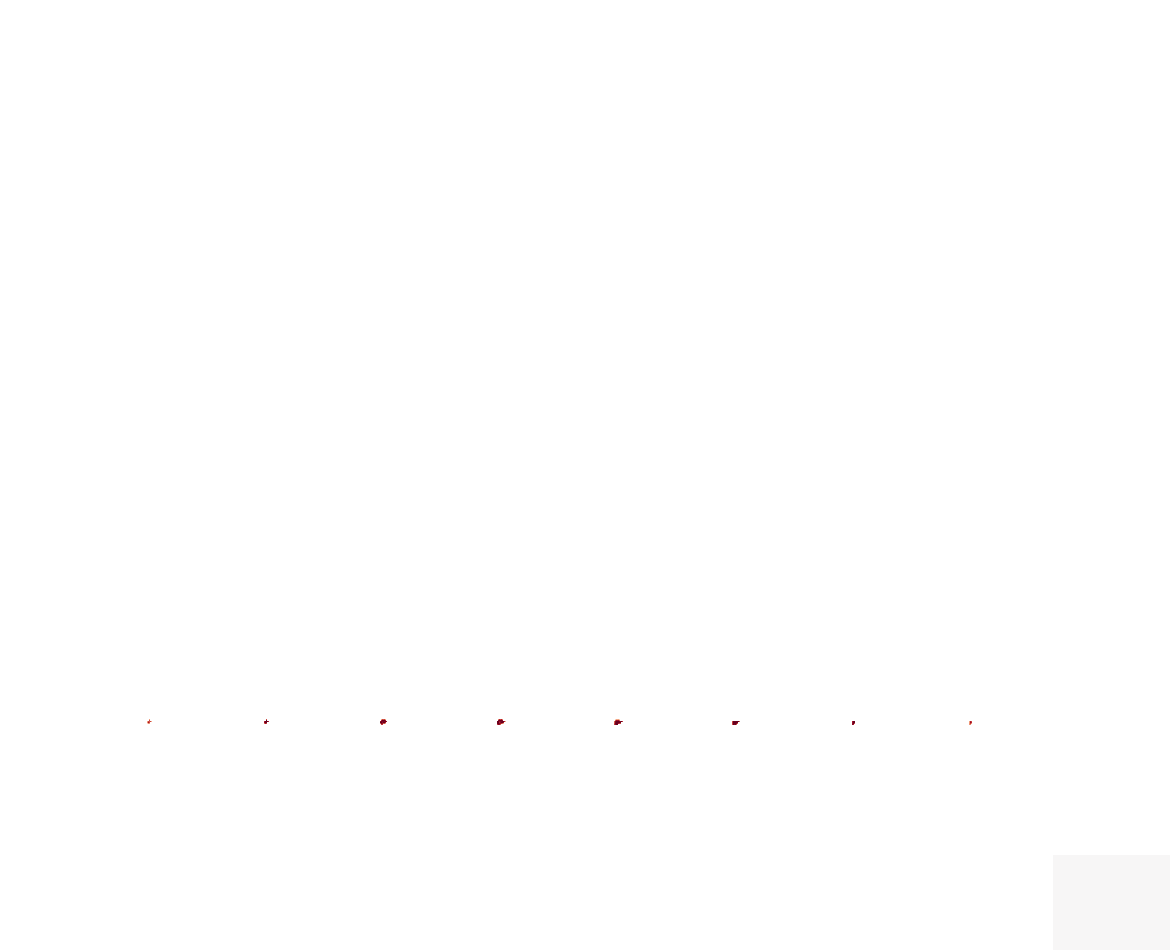

In [12]:
# Interactive glass brain views (FDR 0.001)
for model_name in tmaps:
    tmap = tmaps[model_name][0.001]
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'{model_name} (FDR < 0.001)')
    display(view)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11900\3421304424.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


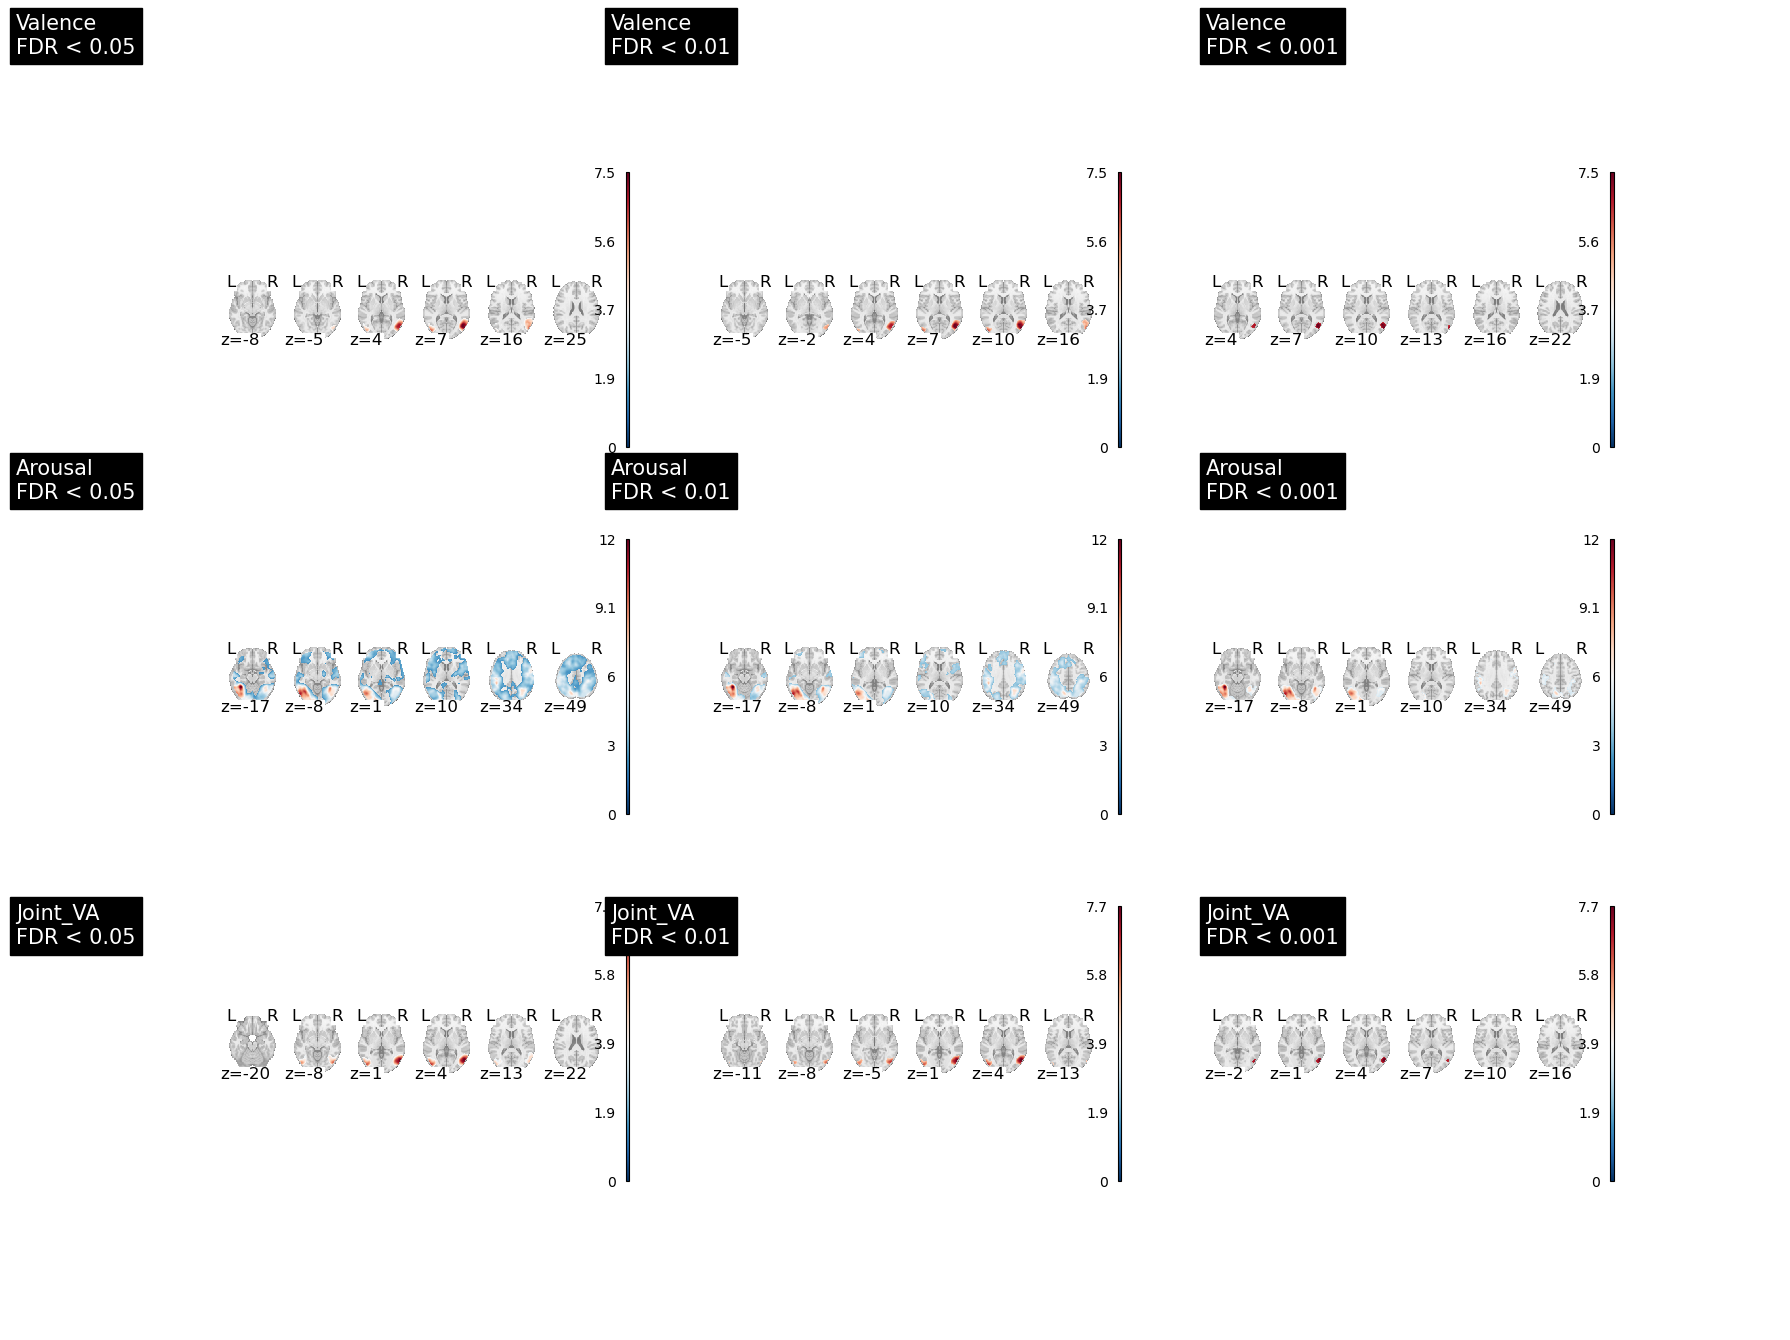

In [13]:
# Static slice views: rows = models, columns = FDR thresholds
model_names_list = list(tmaps.keys())
n_models = len(model_names_list)
n_fdrs = len(FDR_ALPHAS)

fig, axes = plt.subplots(n_models, n_fdrs, figsize=(6 * n_fdrs, 4.5 * n_models))

for row, model_name in enumerate(model_names_list):
    for col, fdr_alpha in enumerate(FDR_ALPHAS):
        tmap = tmaps[model_name][fdr_alpha]
        plotting.plot_stat_map(
            tmap, display_mode='z', cut_coords=6,
            title=f'{model_name}\nFDR < {fdr_alpha}',
            axes=axes[row, col],
            threshold=0, colorbar=True
        )

plt.tight_layout()
plt.savefig('./outputs/tmap_valence_arousal_separate_all_fdr.png', dpi=150)
plt.show()

## 7. Reload saved results (if restarting)

In [14]:
# # Reload
# results = {}
# for name in ['Valence', 'Arousal', 'Joint_VA']:
#     eval_scores = np.load(f'./outputs/20sub_SL_eval_{name}.npy')
#     print(f'Reloaded {name}: {eval_scores.shape}')
#     results[name] = {'eval_scores': eval_scores, 'voxel_ids': None}